## Exercise 16
Given is a fish pond with m fishes and m unknown. The population size is to be
estimated. Therefore, at first c fishes are angled from the pond, marked with a spot
of color and thrown back into the pond, a week later r fishes are angled and the
number t of the r fishes determined which have a spot of color.

(a) Simulate the example: a virtual fish pond with m = 500 fishes and the values
c, r ∈ {10, 20, 40, 80}. Execute each simulation 100 times and compare the variations of the results in consideration of the values c, r respectively.


    c   r  Mean_Estimate     Std_Dev
0  10  10      97.619048   10.647943
1  10  20     181.818182   38.569461
2  10  40     327.672956  107.132601
3  10  80     534.779116  229.507471
4  20  10     183.333333   37.267800


C:\Users\david.bucher\AppData\Local\Temp\ipykernel_26600\2563037562.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_estimates.values(), labels=all_estimates.keys())


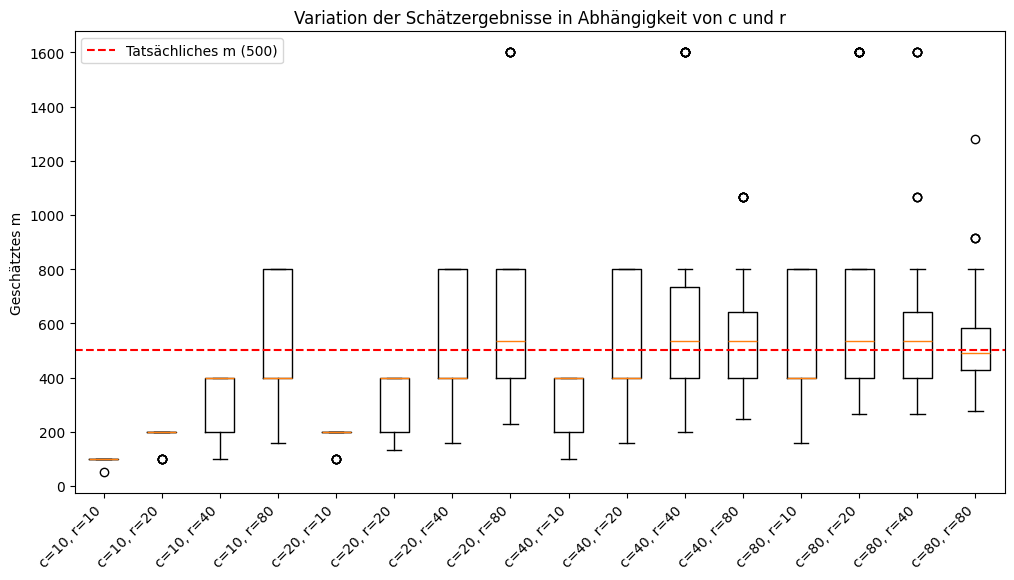

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

m_true = 500
test_values = [10, 20, 40, 80]
iterations = 100

# Store summary results and raw estimates
results_summary = []
all_estimates = {}

np.random.seed(42)

for c in test_values:
    for r in test_values:
        estimates = []
        for _ in range(iterations):
            pond = np.zeros(m_true)
            pond[:c] = 1
            pond = pond[np.random.permutation(len(pond))]  # Shuffle the pond to randomize the positions of the 1s and 0s
            # pond = np.random.choice(pond, size=c, replace=False)
            sample = np.random.choice(pond, size=r, replace=False)
            t = np.sum(sample)
            if t > 0:
                m_hat = (c * r) / t
                estimates.append(m_hat)
            else:
                estimates.append(np.nan) # or np.inf, but let's handle missing/t=0
        
        # Clean estimates for statistics (ignore nan/inf)
        valid_estimates = [x for x in estimates if not np.isnan(x)]
        
        results_summary.append({
            'c': c,
            'r': r,
            'Mean_Estimate': np.mean(valid_estimates) if valid_estimates else np.nan,
            'Std_Dev': np.std(valid_estimates) if valid_estimates else np.nan,
        })
        
        # Keep valid estimates for plotting (cap at 3000 to keep plot readable, as requested before)
        all_estimates[f"c={c}, r={r}"] = [x for x in valid_estimates if x < 3000]

df_results = pd.DataFrame(results_summary)
print(df_results.head())

# Plotting without plt.figure()
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(all_estimates.values(), labels=all_estimates.keys())
ax.axhline(y=500, color='r', linestyle='--', label='Tatsächliches m (500)')
ax.set_ylabel('Geschätztes m')
ax.set_title('Variation der Schätzergebnisse in Abhängigkeit von c und r')
plt.xticks(rotation=45, ha='right')
ax.legend()

## Beweis: Maximum-Likelihood-Schätzer für das Capture-Recapture-Verfahren

Da die Populationsgröße $m$ eine diskrete Variable (ganze Zahl) ist, bestimmen wir das Maximum der Likelihood-Funktion nicht über die Ableitung, sondern über den Quotienten zweier aufeinanderfolgender Werte $L(m)$ und $L(m-1)$. 

Wenn der Quotient $\frac{L(m)}{L(m-1)} > 1$ ist, steigt die Likelihood-Funktion für ein größeres $m$ an.

---

### 1. Aufstellen der Likelihood-Funktionen

Die Anzahl der wiedergefangenen, markierten Fische $t$ folgt einer hypergeometrischen Verteilung. Die Likelihood-Funktion für eine angenommene Population $m$ lautet:

$$L(m) = \frac{\binom{c}{t} \binom{m - c}{r - t}}{\binom{m}{r}}$$

Für eine um eins kleinere Population $m-1$ gilt entsprechend:

$$L(m-1) = \frac{\binom{c}{t} \binom{m - 1 - c}{r - t}}{\binom{m - 1}{r}}$$

---

### 2. Aufstellen und Kürzen des Quotienten

Wir teilen $L(m)$ durch $L(m-1)$. Dabei kürzt sich der Faktor $\binom{c}{t}$ im Zähler direkt weg:

$$\frac{L(m)}{L(m-1)} = \frac{\binom{m - c}{r - t}}{\binom{m - 1 - c}{r - t}} \cdot \frac{\binom{m - 1}{r}}{\binom{m}{r}}$$

Unter Verwendung der Identität für Binomialkoeffizienten $\binom{n}{k} = \frac{n}{n-k} \cdot \binom{n-1}{k}$ lassen sich die Brüche wie folgt vereinfachen:

1. **Erster Bruch:**
   $$\frac{\binom{m - c}{r - t}}{\binom{m - 1 - c}{r - t}} = \frac{m - c}{(m - c) - (r - t)} = \frac{m - c}{m - c - r + t}$$

2. **Zweiter Bruch:**
   $$\frac{\binom{m - 1}{r}}{\binom{m}{r}} = \frac{m - r}{m}$$

Multipliziert man beide Terme, ergibt sich der vereinfachte Quotient:

$$\frac{L(m)}{L(m-1)} = \frac{(m - c)(m - r)}{m(m - c - r + t)}$$

---

### 3. Ausmultiplizieren von Zähler und Nenner

Wir lösen die Klammern im Zähler und Nenner auf:

* **Zähler:** $(m - c)(m - r) = m^2 - mr - mc + cr$
* **Nenner:** $m(m - c - r + t) = m^2 - mc - mr + mt$

Daraus folgt:

$$\frac{L(m)}{L(m-1)} = \frac{m^2 - mr - mc + cr}{m^2 - mr - mc + mt}$$

---

### 4. Bestimmung des Maximums (Ungleichung lösen)

Wir suchen den Bereich, in dem die Funktion wächst, setzen den Quotienten also $> 1$:

$$\frac{m^2 - mr - mc + cr}{m^2 - mr - mc + mt} > 1$$

Da der Nenner positiv ist, multiplizieren wir mit dem Nenner durch:

$$m^2 - mr - mc + cr > m^2 - mr - mc + mt$$

Wir subtrahieren die auf beiden Seiten identischen Terme $m^2$, $-mr$ und $-mc$:

$$cr > mt$$

Isolieren von $m$ durch Teilen durch $t$ liefert:

$$m < \frac{c \cdot r}{t}$$

---

### Fazit

* Für alle $m < \frac{c \cdot r}{t}$ gilt $\frac{L(m)}{L(m-1)} > 1$, d.h. die Likelihood-Funktion **steigt**.
* Für alle $m > \frac{c \cdot r}{t}$ kehrt sich das Verhalten um, d.h. die Likelihood-Funktion **fällt**.

Das Maximum der Likelihood-Funktion liegt somit genau an der Stelle des Vorzeichenwechsels. Der Maximum-Likelihood-Schätzer $\hat{m}$ lautet daher:

$$\hat{m} = \frac{c \cdot r}{t}$$

# Exercise 17
Let X ∼ P ark,xmin be Pareto-distributed with parameters k > 0 and xmin > 0. This
distribution is often used in economics. Its expectation is given by:
E[X] = xmin ·
k
k − 1
Assume, we are given data 30, 100, 120, 250, 57 sampled from a Pareto and let xmin = 30,
the minimum value of the data. Find an estimator for the parameter k using the
Method-of-Moments and calculate its value. Plot data and distribution density in a
chart.

Stichprobenmittelwert (x_quer): 111.40
Geschätztes k (k_hat): 1.3686


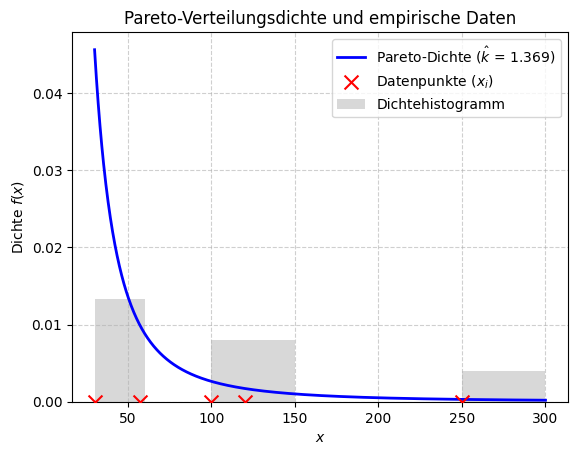

In [5]:
# 1. Gegebene Daten definieren
data = np.array([30, 100, 120, 250, 57])
x_min = 30

# 2. Stichprobenmittelwert berechnen
mean_x = np.mean(data)

# 3. Momentenmethode-Schätzer für k berechnen
# Formel: k = mean / (mean - x_min)
k_hat = mean_x / (mean_x - x_min)

print(f"Stichprobenmittelwert (x_quer): {mean_x:.2f}")
print(f"Geschätztes k (k_hat): {k_hat:.4f}")

# 4. Visualisierung der Dichtefunktion und der Daten
# x-Werte für den Verlauf der Dichtefunktion generieren
x_vals = np.linspace(x_min, 300, 1000)

# Pareto-Dichtefunktion: f(x) = (k * x_min^k) / x^(k+1)
pdf_vals = (k_hat * (x_min**k_hat)) / (x_vals**(k_hat + 1))

# Theoretische Dichtekurve plotten
plt.plot(x_vals, pdf_vals, label=f'Pareto-Dichte ($\\hat{{k}}$ = {k_hat:.3f})', color='blue', linewidth=2)

# Reale Datenpunkte auf der x-Achse einzeichnen (Rug Plot)
plt.scatter(data, np.zeros_like(data), color='red', zorder=5, label='Datenpunkte ($x_i$)', marker='x', s=100)

# Ein normiertes Histogramm zur Veranschaulichung hinzufügen
plt.hist(data, bins=[30, 60, 100, 150, 250, 300], density=True, alpha=0.3, color='gray', label='Dichtehistogramm')

# Diagrammbeschriftungen
plt.title('Pareto-Verteilungsdichte und empirische Daten')
plt.xlabel('$x$')
plt.ylabel('Dichte $f(x)$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Diagramm speichern
plt.savefig('pareto_estimation.png', bbox_inches='tight')

# Exercise 18
Plot the distribution function and the density of a (student-) t-distribution with varying degrees of freedom n ∈ {1, 2, 3, 5, 10} on top of the density of a standard normal
distribution and discuss the similarities/differences you can find. In a simulation, generate 3 random numbers from the standard normal distribution N (0, 1), estimate
mean and variance by µˆ = numpy.mean(data) and σˆ
2 = numpy.var(data, ddof=1).
Finally compute
$$S = \frac{\hat{\mu}}{\sqrt{\hat{\sigma}^2} / \sqrt{n}}$$
Repeat this experiment m = 1000 times and add the empirical distribution function
of S1, . . . , Sm to the plot of the distribution function. To which distribution does the
resulting data compare best?


<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david.bucher\AppData\Local\Temp\ipykernel_26600\2780851168.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, stats.norm.pdf(x), label='Standard Normal $\mathcal{N}(0,1)$', color='black', lw=2, linestyle='--')
C:\Users\david.bucher\AppData\Local\Temp\ipykernel_26600\2780851168.py:30: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, stats.norm.cdf(x), label='Standard Normal $\mathcal{N}(0,1)$', color='black', lw=2, linestyle='--')


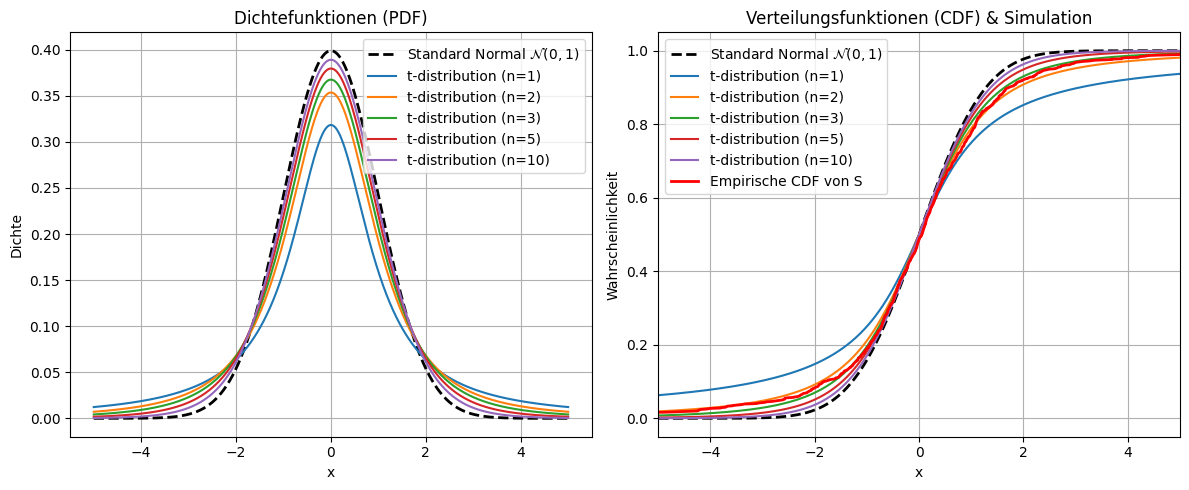

In [6]:
import scipy.stats as stats

# Parameter definieren
degrees_of_freedom = [1, 2, 3, 5, 10]
x = np.linspace(-5, 5, 1000)

# ==========================================
# 1. PLOT: Dichtefunktionen (PDF)
# ==========================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Standardnormalverteilung plotten
plt.plot(x, stats.norm.pdf(x), label='Standard Normal $\mathcal{N}(0,1)$', color='black', lw=2, linestyle='--')
# t-Verteilungen plotten
for n in degrees_of_freedom:
    plt.plot(x, stats.t.pdf(x, df=n), label=f't-distribution (n={n})')

plt.title('Dichtefunktionen (PDF)')
plt.xlabel('x')
plt.ylabel('Dichte')
plt.legend()
plt.grid(True)

# ==========================================
# 2. PLOT: Verteilungsfunktionen (CDF) + Simulation
# ==========================================
plt.subplot(1, 2, 2)
# Standardnormalverteilung plotten
plt.plot(x, stats.norm.cdf(x), label='Standard Normal $\mathcal{N}(0,1)$', color='black', lw=2, linestyle='--')
# t-Verteilungen plotten
for n in degrees_of_freedom:
    plt.plot(x, stats.t.cdf(x, df=n), label=f't-distribution (n={n})')

# --- Simulation ---
m = 1000  # Anzahl der Wiederholungen
sample_size = 3  # "generate 3 random numbers" -> Achtung: In der Formel ist n die Stichprobengröße!
S_values = []

for _ in range(m):
    # 3 Zufallszahlen aus N(0,1) ziehen
    data = np.random.normal(0, 1, size=sample_size)
    mu_hat = np.mean(data)
    sigma_hat_sq = np.var(data, ddof=1)
    
    # Berechnung von S nach der Formel im Bild:
    # Hinweis: In der Formel steht \sqrt{n} im Nenner. Da wir 3 Zahlen ziehen, ist hier n = 3.
    S = mu_hat / (np.sqrt(sigma_hat_sq) / np.sqrt(sample_size))
    S_values.append(S)

# Empirische Verteilungsfunktion (ECDF) berechnen und plotten
S_sorted = np.sort(S_values)
y_ecdf = np.arange(1, m + 1) / m
plt.plot(S_sorted, y_ecdf, label='Empirische CDF von S', color='red', lw=2)

plt.title('Verteilungsfunktionen (CDF) & Simulation')
plt.xlabel('x')
plt.ylabel('Wahrscheinlichkeit')
plt.xlim([-5, 5]) # Fokus auf den gleichen Bereich
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Zusammenfassung der Ergebnisse

Hier ist die kurze und prägnante Zusammenfassung der Ergebnisse basierend auf deinen Plots:

### 1. Vergleich der Dichtefunktionen (PDF)

* **Form:** Sowohl die Standardnormalverteilung als auch die $t$-Verteilungen sind symmetrisch und glockenförmig um den Nullpunkt ($x = 0$) zentriert.
* **Verhalten der Ränder (*"Tails"*):** Die $t$-Verteilungen haben deutlich höhere Ränder (sogenannte *Heavy Tails*) und ein flacheres Maximum als die Normalverteilung. Das bedeutet, dass extreme Werte bei ihnen wahrscheinlicher sind.
* **Einfluss der Freiheitsgrade ($n$):** * Je kleiner $n$ ist, desto ausgeprägter sind diese schweren Ränder (Extremfall: $n=1$).
  * Je größer $n$ wird, desto näher schmiegt sich die $t$-Verteilung an die Standardnormalverteilung an.

---

### 2. Ergebnis der Simulation (CDF)

* **Zugehörigkeit von $S$:** Die simulierte rote Kurve (*"Empirische CDF von $S$"*) deckt sich im rechten Plot fast perfekt mit der theoretischen Kurve der $t$-Verteilung mit $n=2$ (orangefarbene Linie).
* **Mathematischer Grund:** Es wurden Stichproben vom Umfang $n_{\text{sample}} = 3$ gezogen. Da bei der Berechnung von $S$ die Standardabweichung aus den Daten geschätzt werden muss, folgt die Statistik mathematisch einer $t$-Verteilung mit $n_{\text{sample}} - 1$ Freiheitsgraden.

> **Fazit:** Das Ergebnis zeigt exakt das theoretisch erwartete Verhalten: $3 - 1 = 2$ Freiheitsgrade.